### 🧠 What is Query Planning and Decomposition?
Query Planning and Decomposition is a technique where a complex user query is broken down into simpler sub-questions or tasks, allowing a system (like a RAG agent) to:

- Understand the question more deeply
- Retrieve more precise and complete information
- Execute step-by-step reasoning

It's like reverse-engineering a question into manageable steps before answering.

🧠 What's New in This Version?
- ✅ Add a Query Planner Node
- ✅ Break complex user queries into sub-questions
- ✅ Retrieve docs per sub-question
- ✅ Combine all retrieved contexts
- ✅ Generate a final consolidated answer

In [24]:
import os
from typing import List, TypedDict
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader, WebBaseLoader
from langgraph.graph import StateGraph, END
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from IPython.display import Markdown, display

In [2]:
load_dotenv()

True

In [3]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

In [12]:
llm = init_chat_model("openai:gpt-4o")

In [5]:
# ----------------------------
# 1. Load and Embed Documents
# ----------------------------
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]

docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [6]:
# ----------------------------
# 2. State Schema
# ----------------------------
class RAGState(TypedDict):
    question: str
    sub_questions: List[str]
    retrieved_docs: List[Document]
    answer: str

In [21]:
# ----------------------------
# 3. Nodes
# ----------------------------
## a. Query Planner: splits input question
def plan_query(state: RAGState) -> dict:
   
    
    prompt = PromptTemplate(
        template = """
        Break the following complex question into 2-3 sub-questions seperated by newline:

        Question: {question}

        Sub-questions:
        """,
        input_variables=['question']
    )

    chain = prompt|llm|StrOutputParser()
    result = chain.invoke({"question": state['question']})
    sub_questions = [line.strip("- ").strip() for line in result.strip().split("\n") if line.strip()]
    return {"sub_questions" : sub_questions}

## b. Retrieve documents for each sub-question
def retrieve_for_each(state: RAGState) -> dict:
    all_docs = []
    for sub_q in state['sub_questions']:
        docs = retriever.invoke(sub_q)
        all_docs.extend(docs)
    return {"retrieved_docs": all_docs}

## c. Generate final answer
def generate_final_answer(state: RAGState) -> dict:
    context = "\n\n".join([doc.page_content for doc in state['retrieved_docs']])
    
    prompt = PromptTemplate(
        template = """
        Use the context below to answer the question.

        Context:
        {context}

        Question: {question}
        """,
        input_variables=['context', 'question']
    )
    chain = prompt|llm|StrOutputParser()
    
    answer = chain.invoke({"question": state['question'], "context": context})
    return {"answer": answer}

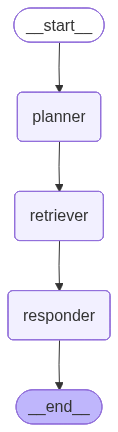

In [22]:
# ----------------------------
# 4. Build LangGraph
# ----------------------------
builder = StateGraph(RAGState)

builder.add_node("planner", plan_query)
builder.add_node("retriever", retrieve_for_each)
builder.add_node("responder", generate_final_answer)

builder.set_entry_point("planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [25]:
user_query = "Explain how agent loops work and what are the challenges in diffusion video generation?"
initial_state =  RAGState(question=user_query)
final_state = graph.invoke(initial_state)

print("\n🔍 Sub-questions:")
for q in final_state['sub_questions']:
    print("-", q)

print("\n✅ Final Answer:\n")
display(Markdown(final_state['answer']))


🔍 Sub-questions:
- 1. How do agent loops function and what are their key components in system operations?
- 2. What are the main challenges encountered in diffusion video generation, and how do they impact the process?

✅ Final Answer:



Agent loops typically refer to the iterative processes involved in the functioning of an autonomous agent system, particularly one powered by large language models (LLMs). In such systems, the agent loop involves several key components and steps that allow the agent to process inputs, generate outputs, and learn from the interactions over time. Here is a general overview of how agent loops work:

1. **Perception:** The agent receives input from its environment. This could be in the form of text data, user queries, sensory inputs from the real world, or interactions with other agents.

2. **Memory:** Information received by the agent is stored in memory. This memory serves as a repository of past experiences and interactions that the agent can draw from to inform future actions.

3. **Planning:** Based on the input and its stored memory, the agent develops a plan of action. This involves decomposing tasks into manageable steps and strategizing on how to achieve the desired outcome.

4. **Action:** The agent executes the planned actions. This could involve generating responses, performing computations, interacting with other agents, or modifying its environment.

5. **Reflection:** After executing actions, the agent evaluates the outcomes. It reflects on what it learned from the interactions and updates its understanding or strategy if necessary.

6. **Learning:** Circularly, the agent incorporates the outcomes into its memory and knowledge base, thus preparing for future tasks and interactions.

**Challenges in Diffusion Video Generation:**

1. **Complexity of Tasks:** Video generation using diffusion models is more complex than image synthesis because a video is essentially a series of frames. Each frame must be coherent with respect to both content and temporal progression.

2. **Upsampling Challenges:** The model needs to perform multiple steps of upsampling to increase the video length or frame rate while ensuring smooth transitions and maintaining consistent quality throughout the generated video.

3. **Conditioning and Continuity:** Generating a coherent video requires conditioning each subsequent segment on the previous frames. This involves complex calculations to ensure that an extension of a video segment ($\mathbf{x}^b$) is consistent with the initial segment ($\mathbf{x}^a$).

4. **Autoregressive Extensions:** There’s a necessity to generate autoregressive extensions of the video frames, where each frame depends on the previously generated ones, introducing challenges in model design and computation.

5. **Completing Missing Frames:** When generating video with low initial frame rates, the model must be capable of predicting and filling in the missing frames without compromising on visual consistency and logical continuity.

These challenges highlight the complexity involved in diffusion video generation and the sophisticated mechanisms required within LLM-centric agent systems to handle such advanced tasks.